# 05 - Tarea: Comparación e interpretación con datos Sophy/Piura

Esta tarea es la segunda entrega evaluada. Es una continuación natural de:

- `01_walkthrough_nowcasting_practico.ipynb`
- `02_tarea_nowcasting_metricas.ipynb`
- `03_comparacion_modelos_post_inferencia.ipynb`

A diferencia de los ejemplos guiados con IDEAM, esta tarea usa **únicamente datos Sophy/Piura**. El objetivo es aplicar el mismo enfoque de evaluación a un caso más cercano al contexto peruano.

**Duración estimada:** 2 a 4 horas  
**Dificultad:** similar a la tarea `02`  
**Entrega:** notebook ejecutado + interpretación breve

## Objetivo

Comparar predicciones de nowcasting sobre eventos de Piura/Sophy usando métricas básicas e interpretación meteorológica.

El estudiante debe responder:

> ¿La predicción mejora frente a persistencia?  
> ¿La mejora se observa en RMSE, en CSI, o en ambos?  
> ¿Qué ocurre con lluvia fuerte o intensa?

Si existen predicciones de EarthFormer o CasCast, se comparan contra persistencia. Si no existen, la tarea se puede completar usando persistencia como línea base y dejando explícita esa limitación.

## 0. Prerrequisitos

Antes de iniciar, verifica que existan datos Sophy/Piura. En el ambiente local del curso se encuentran en:

```text
/home/henryjuarez/code_andre_sophy/curso_hf/dataset/piura_data
```

También puedes colocar los archivos en:

```text
nowcasting_course_lab/data/piura_data/
```

Formato esperado:

```text
(T, H, W) = (25, 128, 128)
```

Convención:

```text
primeros 13 frames = input/contexto
últimos 12 frames = target/futuro
```

In [1]:
from pathlib import Path
import sys
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from course_utils.palette import apply_course_style, RAIN_LEVELS
from course_utils.plotting import plot_event_grid, plot_target_prediction_panel, plot_rmse_bias, plot_csi_by_threshold

apply_course_style()

# Esta tarea usa unicamente datos Sophy/Piura.
# El notebook busca primero dentro del repo del curso y luego en la ruta local de trabajo.
PIURA_DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "piura_data",
    PROJECT_ROOT.parent / "curso_hf" / "dataset" / "piura_data",
    Path("/home/henryjuarez/code_andre_sophy/curso_hf/dataset/piura_data"),
]

PIURA_DATA_DIR = next((p for p in PIURA_DATA_CANDIDATES if p.exists()), None)
if PIURA_DATA_DIR is None:
    raise FileNotFoundError(
        "No encontre datos Piura/Sophy. Colocalos en data/piura_data/ "
        "o ajusta PIURA_DATA_DIR manualmente."
    )

PIURA_FILES = sorted([p.name for p in PIURA_DATA_DIR.glob("*.npy")])
LEAD_MINUTES = np.arange(5, 65, 5)
THRESHOLDS = [0.5, 2.0, 5.0, 10.0]
INPUT_FRAMES = 13
PRED_FRAMES = 12

PREDICTION_ROOT = PROJECT_ROOT / "outputs" / "predictions"
MODEL_DIRS = {
    "earthformer": PREDICTION_ROOT / "earthformer",
    "cascast": PREDICTION_ROOT / "cascast",
    "model": PREDICTION_ROOT / "model",
}

print("Directorio Piura/Sophy:", PIURA_DATA_DIR)
print("Numero de archivos Piura/Sophy:", len(PIURA_FILES))
print("Primeros archivos:", PIURA_FILES[:3])

Directorio Piura/Sophy: C:\Users\Pedro Lopevia\Escritorio\S04-nowcasting-course-lab\data\piura_data
Numero de archivos Piura/Sophy: 118
Primeros archivos: ['piura_furuno_rr_seq_20250326_0000_len25_stride12.npy', 'piura_furuno_rr_seq_20250326_0100_len25_stride12.npy', 'piura_furuno_rr_seq_20250326_0200_len25_stride12.npy']


## 1. Funciones de carga para Piura/Sophy

Completa o revisa estas funciones. La limpieza de NaN es importante porque algunas zonas pueden representar ausencia de eco o regiones fuera del radar.

In [2]:
def clean_rain_array(array):
    """Convierte NaN/Inf a 0 y devuelve float32."""
    return np.nan_to_num(array.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)


def load_piura_sample(filename):
    path = PIURA_DATA_DIR / filename
    sequence = clean_rain_array(np.load(path))
    if sequence.ndim != 3 or sequence.shape[0] != 25:
        raise ValueError(f"Forma inesperada para {filename}: {sequence.shape}")
    return sequence


def split_sequence(sequence):
    inputs = sequence[:INPUT_FRAMES]
    target = sequence[INPUT_FRAMES:INPUT_FRAMES + PRED_FRAMES]
    return inputs, target


def make_persistence_prediction(inputs):
    """Repite el ultimo frame observado para los 12 tiempos futuros."""
    last_frame = inputs[-1]
    return np.repeat(last_frame[None, :, :], PRED_FRAMES, axis=0).astype(np.float32)


def parse_piura_datetime(filename):
    """Extrae fecha/hora desde nombres tipo piura_furuno_rr_seq_20250326_1400_len25_stride12.npy."""
    match = re.search(r"seq_(\d{8})_(\d{4})", filename)
    if match is None:
        return "unknown"
    date, hour = match.groups()
    return f"{date[:4]}-{date[4:6]}-{date[6:8]} {hour[:2]}:{hour[2:]}"

## 2. Auditoría rápida de los eventos Piura/Sophy

Construye una tabla simple para entender los casos antes de evaluar modelos.

Debe incluir:

- archivo;
- fecha/hora;
- máximo de lluvia;
- lluvia media;
- fracción de pixeles con lluvia `>= 0.5 mm/h`;
- fracción de pixeles con lluvia fuerte `>= 5 mm/h`.

In [3]:
def build_piura_audit(files=PIURA_FILES):
    rows = []
    for filename in files:
        sequence = load_piura_sample(filename)
        rows.append({
            "filename": filename,
            "datetime": parse_piura_datetime(filename),
            "n_frames": sequence.shape[0],
            "H": sequence.shape[1],
            "W": sequence.shape[2],
            "max_rain_rate": float(np.nanmax(sequence)),
            "mean_rain_rate": float(np.nanmean(sequence)),
            "rainy_pixel_fraction": float((sequence >= 0.5).mean()),
            "heavy_rain_pixel_fraction": float((sequence >= 5.0).mean()),
        })
    return pd.DataFrame(rows)

piura_audit = build_piura_audit()
piura_audit

,filename,datetime,n_frames,H,W,max_rain_rate,mean_rain_rate,rainy_pixel_fraction,heavy_rain_pixel_fraction
0,piura_furuno_rr_seq_20250326_0000_len25_stride...,2025-03-26 00:00,25,128,128,37.419998,0.017061,0.003879,0.000933
1,piura_furuno_rr_seq_20250326_0100_len25_stride...,2025-03-26 01:00,25,128,128,17.414444,0.002124,0.000764,0.000085
2,piura_furuno_rr_seq_20250326_0200_len25_stride...,2025-03-26 02:00,25,128,128,10.244444,0.001089,0.000740,0.000012
3,piura_furuno_rr_seq_20250326_0300_len25_stride...,2025-03-26 03:00,25,128,128,31.481113,0.002113,0.001296,0.000046
4,piura_furuno_rr_seq_20250326_0400_len25_stride...,2025-03-26 04:00,25,128,128,31.481113,0.001757,0.001006,0.000046
...,...,...,...,...,...,...,...,...,...
113,piura_furuno_rr_seq_20250330_1700_len25_stride...,2025-03-30 17:00,25,128,128,118.755005,0.319842,0.032434,0.015159
114,piura_furuno_rr_seq_20250330_1800_len25_stride...,2025-03-30 18:00,25,128,128,124.121109,0.641808,0.053640,0.027446
115,piura_furuno_rr_seq_20250330_1900_len25_stride...,2025-03-30 19:00,25,128,128,327.670013,1.096772,0.067419,0.040803
116,piura_furuno_rr_seq_20250330_2000_len25_stride...,2025-03-30 20:00,25,128,128,327.670013,1.343595,0.073386,0.047842


## 3. Elegir un caso y visualizarlo

Escoge un archivo de Piura/Sophy. Observa el movimiento de la precipitación y los núcleos intensos.

Caso: piura_furuno_rr_seq_20250326_0000_len25_stride12.npy
Fecha/hora: 2025-03-26 00:00
inputs: (13, 128, 128) target: (12, 128, 128) persistence: (12, 128, 128)


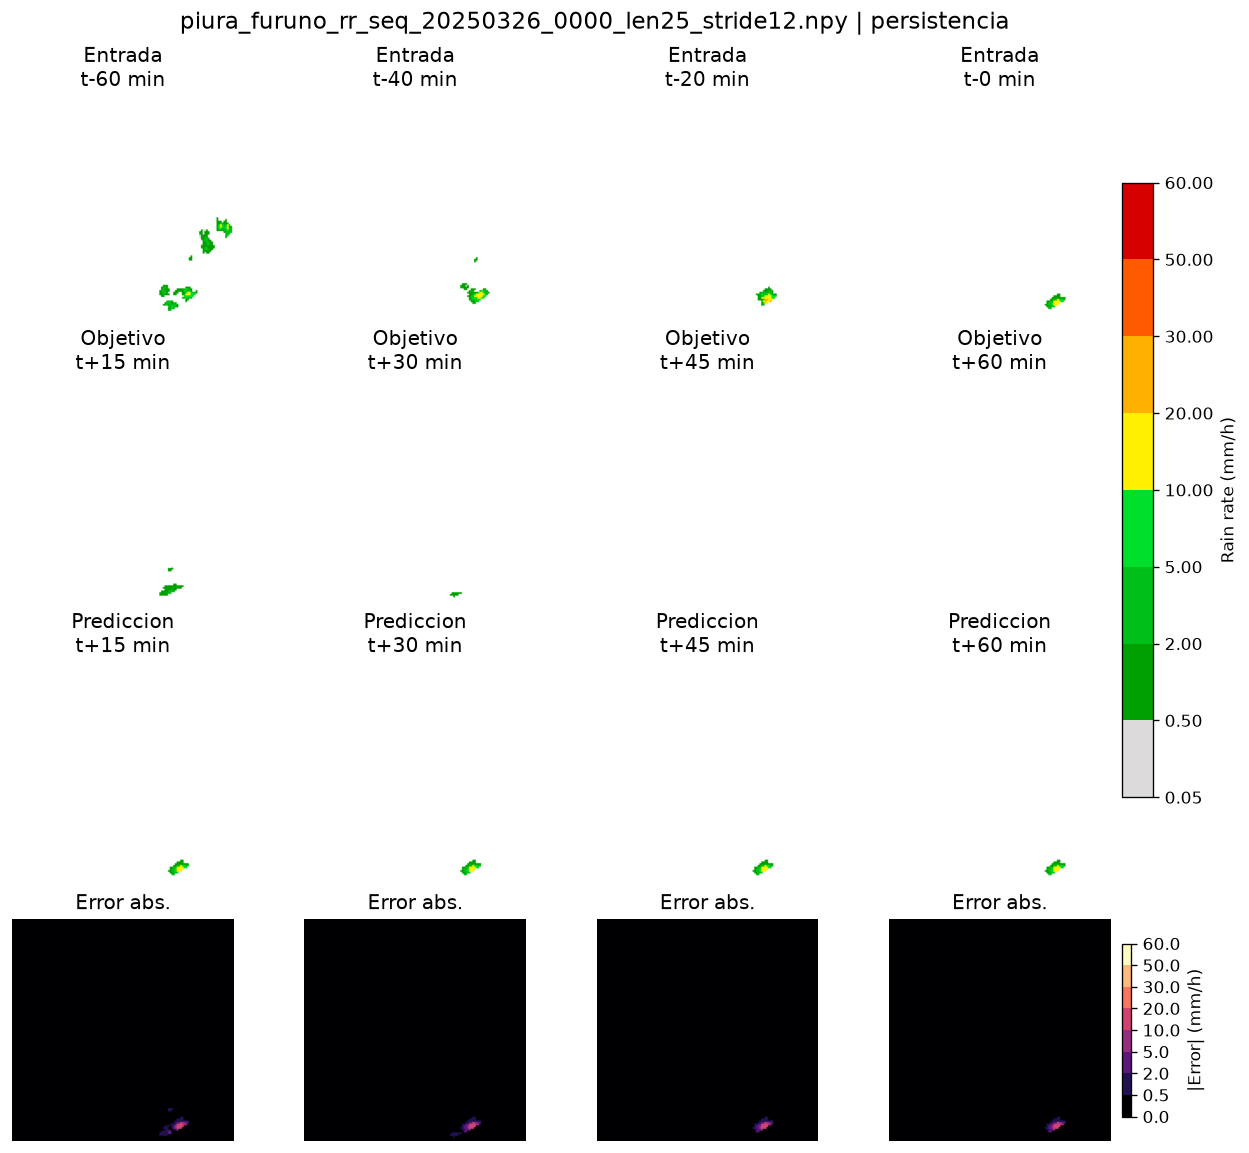

In [4]:
sample_name = PIURA_FILES[0]
sequence = load_piura_sample(sample_name)
inputs, target = split_sequence(sequence)
persistence = make_persistence_prediction(inputs)

print("Caso:", sample_name)
print("Fecha/hora:", parse_piura_datetime(sample_name))
print("inputs:", inputs.shape, "target:", target.shape, "persistence:", persistence.shape)

fig = plot_event_grid(inputs, target, persistence, sample_name, "persistencia", lead_indices=(2, 5, 8, 11))
plt.show()

## 4. Métricas: reutilizar lo aprendido en la tarea 02

Aquí debes implementar o pegar las funciones que completaste en `02_tarea_nowcasting_metricas.ipynb`.

Funciones requeridas:

- `safe_pearson`
- `compute_continuous_metrics`
- `safe_divide`
- `compute_binary_metrics`
- `compute_event_metrics`

Esta tarea busca evaluar e interpretar, no introducir métricas mucho más difíciles.

In [5]:
def safe_pearson(x, y):
    """Correlación de Pearson segura entre dos campos 2D."""
    x = np.asarray(x, dtype=np.float64).ravel()
    y = np.asarray(y, dtype=np.float64).ravel()
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    if x.size < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def compute_continuous_metrics(pred, target):
    """Devuelve DataFrame con lead_min, MAE, RMSE, Bias, Pearson_r."""
    rows = []
    for i, lead in enumerate(LEAD_MINUTES):
        error = pred[i] - target[i]
        rows.append({
            "lead_min": int(lead),
            "MAE": float(np.nanmean(np.abs(error))),
            "RMSE": float(np.sqrt(np.nanmean(error**2))),
            "Bias": float(np.nanmean(error)),
            "Pearson_r": safe_pearson(pred[i], target[i]),
        })
    return pd.DataFrame(rows)


def safe_divide(numerator, denominator):
    """Devuelve np.nan si denominator == 0."""
    return np.nan if denominator == 0 else float(numerator / denominator)


def compute_binary_metrics(pred, target, threshold):
    """Calcula TP, FP, FN, TN, CSI, POD, FAR, Precision, Recall, F1."""
    pred_event = np.asarray(pred) >= threshold
    target_event = np.asarray(target) >= threshold
    tp = int(np.logical_and(pred_event, target_event).sum())
    fp = int(np.logical_and(pred_event, ~target_event).sum())
    fn = int(np.logical_and(~pred_event, target_event).sum())
    tn = int(np.logical_and(~pred_event, ~target_event).sum())
    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "CSI": safe_divide(tp, tp + fp + fn),
        "POD": safe_divide(tp, tp + fn),
        "FAR": safe_divide(fp, tp + fp),
        "Precision": safe_divide(tp, tp + fp),
        "Recall": safe_divide(tp, tp + fn),
        "F1": safe_divide(2 * tp, 2 * tp + fp + fn),
    }


def compute_event_metrics(pred, target, thresholds=THRESHOLDS):
    """Métricas por lead time y umbral."""
    rows = []
    for threshold in thresholds:
        for i, lead in enumerate(LEAD_MINUTES):
            metrics = compute_binary_metrics(pred[i], target[i], threshold)
            rows.append({
                "threshold_mm_h": threshold,
                "threshold_label": f"{threshold:g} mm/h",
                "lead_min": int(lead),
                **metrics
            })
    return pd.DataFrame(rows)


## 5. Predicciones disponibles para Piura/Sophy

Esta función busca predicciones guardadas con el mismo nombre del archivo en:

```text
outputs/predictions/earthformer/
outputs/predictions/cascast/
outputs/predictions/model/
```

Si no existen, al menos se evalúa persistencia.

In [6]:
def available_predictions_for_piura_case(filename):
    sequence = load_piura_sample(filename)
    inputs, target = split_sequence(sequence)
    predictions = {"persistence": make_persistence_prediction(inputs)}

    for model_name, folder in MODEL_DIRS.items():
        pred_path = folder / filename
        if pred_path.exists():
            predictions[model_name] = clean_rain_array(np.load(pred_path))

    return inputs, target, predictions

inputs, target, predictions = available_predictions_for_piura_case(sample_name)
print("Predicciones disponibles:", list(predictions))

Predicciones disponibles: ['persistence']


## 6. Comparación visual por modelo

Compara los modelos disponibles para un mismo caso. Si solo hay persistencia, discute esa limitación.

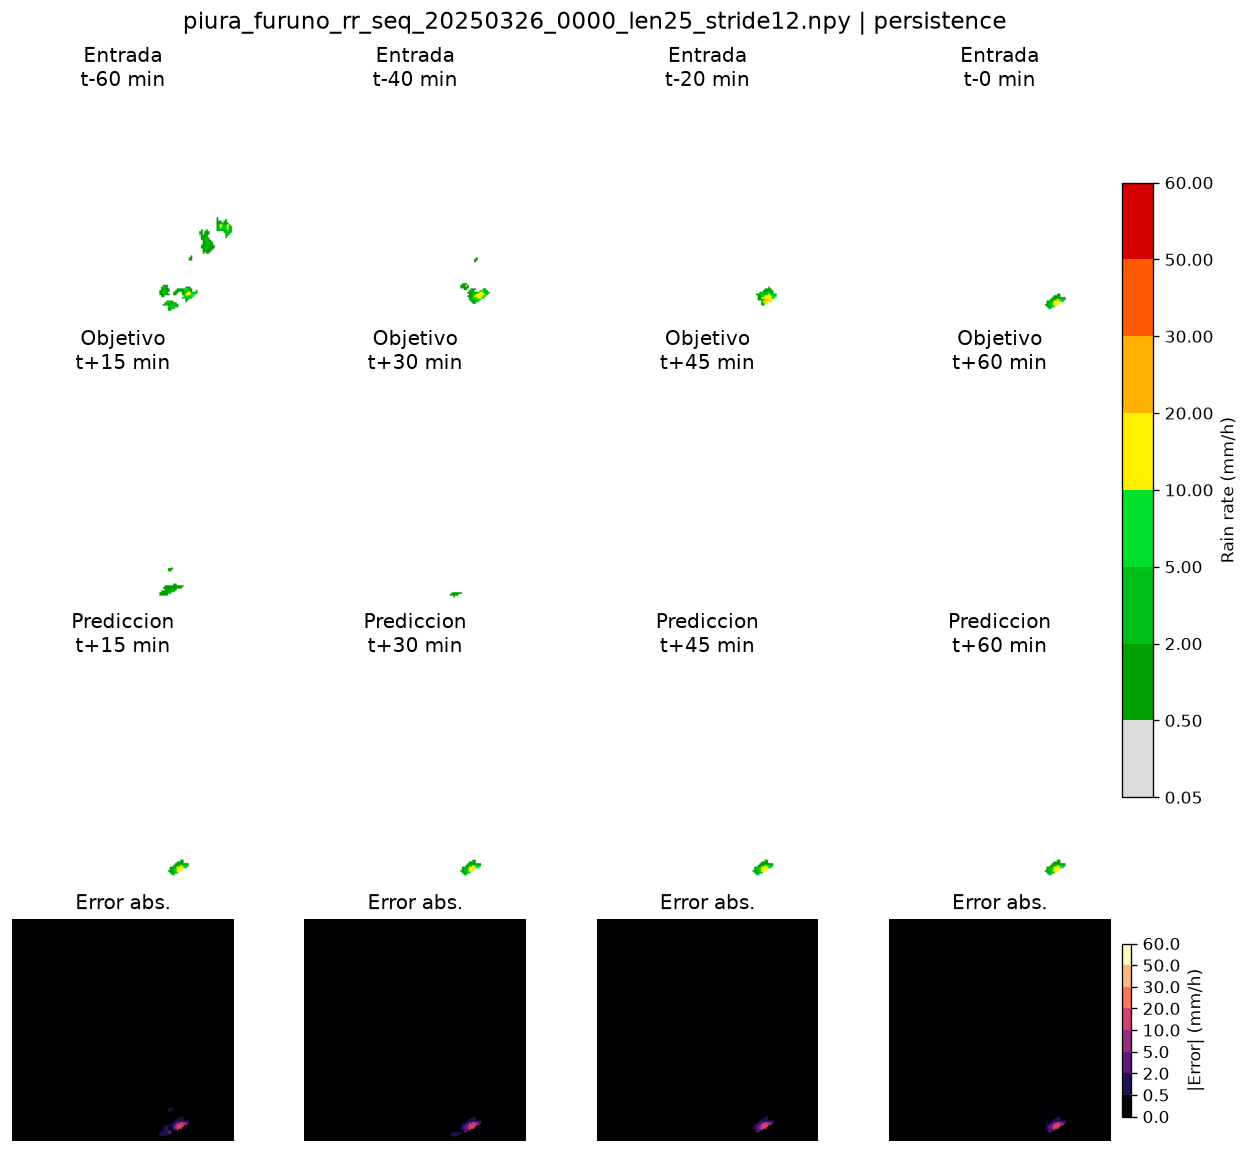

In [7]:
for model_name, pred in predictions.items():
    fig = plot_event_grid(inputs, target, pred, sample_name, model_name, lead_indices=(2, 5, 8, 11))
    plt.show()

## 7. Evaluación de un caso

Cuando completes tus funciones de métricas, calcula las tablas para cada modelo disponible.

In [8]:
case_rows = []
for model_name, pred in predictions.items():
    continuous_df = compute_continuous_metrics(pred, target)
    event_df = compute_event_metrics(pred, target, THRESHOLDS)
    case_rows.append({
        "sample": sample_name,
        "model": model_name,
        "RMSE_mean": continuous_df["RMSE"].mean(),
        "MAE_mean": continuous_df["MAE"].mean(),
        "Bias_mean": continuous_df["Bias"].mean(),
        "Pearson_mean": continuous_df["Pearson_r"].mean(),
        "CSI_0.5_mean": event_df[event_df["threshold_mm_h"] == 0.5]["CSI"].mean(),
        "CSI_5_mean": event_df[event_df["threshold_mm_h"] == 5.0]["CSI"].mean(),
        "CSI_10_mean": event_df[event_df["threshold_mm_h"] == 10.0]["CSI"].mean(),
    })

case_summary = pd.DataFrame(case_rows)
case_summary


,sample,model,RMSE_mean,MAE_mean,Bias_mean,Pearson_mean,CSI_0.5_mean,CSI_5_mean,CSI_10_mean
0,piura_furuno_rr_seq_20250326_0000_len25_stride...,persistence,0.422547,0.01902,0.01603,0.281898,0.127247,0.017857,0.0


## 8. Pipeline para todos los casos Piura/Sophy

Ahora aplica el mismo análisis a todos los archivos de Piura/Sophy.

Tabla requerida:

| sample | datetime | model | RMSE_mean | Bias_mean | CSI_0.5_mean | CSI_5_mean | CSI_10_mean |
|---|---|---:|---:|---:|---:|---:|

In [9]:
def evaluate_all_piura_cases(files=PIURA_FILES):
    """Evalúa todos los archivos Piura/Sophy y todos los modelos disponibles."""
    rows = []
    eval_files = [files[i] for i in np.linspace(0, len(files)-1, 15, dtype=int)]
    for filename in eval_files:
        inputs, target, preds = available_predictions_for_piura_case(filename)
        dt = parse_piura_datetime(filename)
        for model_name, pred in preds.items():
            continuous_df = compute_continuous_metrics(pred, target)
            event_df = compute_event_metrics(pred, target, THRESHOLDS)
            rows.append({
                "sample": filename,
                "datetime": dt,
                "model": model_name,
                "RMSE_mean": float(continuous_df["RMSE"].mean()),
                "MAE_mean": float(continuous_df["MAE"].mean()),
                "Bias_mean": float(continuous_df["Bias"].mean()),
                "Pearson_mean": float(continuous_df["Pearson_r"].mean()),
                "CSI_0.5_mean": float(event_df[event_df["threshold_mm_h"] == 0.5]["CSI"].mean()),
                "CSI_5_mean": float(event_df[event_df["threshold_mm_h"] == 5.0]["CSI"].mean()),
                "CSI_10_mean": float(event_df[event_df["threshold_mm_h"] == 10.0]["CSI"].mean()),
            })
    return pd.DataFrame(rows)


In [10]:
piura_summary = evaluate_all_piura_cases()
piura_summary


,sample,datetime,model,RMSE_mean,MAE_mean,Bias_mean,Pearson_mean,CSI_0.5_mean,CSI_5_mean,CSI_10_mean
0,piura_furuno_rr_seq_20250326_0000_len25_stride...,2025-03-26 00:00,persistence,0.422547,0.019020,0.016030,0.281898,0.127247,0.017857,0.000000
1,piura_furuno_rr_seq_20250326_0800_len25_stride...,2025-03-26 08:00,persistence,2.993823,0.712521,-0.143120,0.427830,0.435087,0.315854,0.162502
2,piura_furuno_rr_seq_20250326_1600_len25_stride...,2025-03-26 16:00,persistence,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
3,piura_furuno_rr_seq_20250327_0100_len25_stride...,2025-03-27 01:00,persistence,3.666753,1.632702,0.665811,0.645839,0.597583,0.430173,0.330883
4,piura_furuno_rr_seq_20250327_0900_len25_stride...,2025-03-27 09:00,persistence,0.009847,0.000223,-0.000223,NaN,0.000000,NaN,NaN
5,piura_furuno_rr_seq_20250327_1700_len25_stride...,2025-03-27 17:00,persistence,1.975557,0.178802,-0.152423,0.196495,0.149105,0.098941,0.075170
6,piura_furuno_rr_seq_20250328_0200_len25_stride...,2025-03-28 02:00,persistence,2.583279,0.921228,0.225591,0.667594,0.548869,0.314307,0.304885
7,piura_furuno_rr_seq_20250328_1000_len25_stride...,2025-03-28 10:00,persistence,1.610118,0.525483,0.030123,0.404094,0.429968,0.103029,0.047284
8,piura_furuno_rr_seq_20250328_1800_len25_stride...,2025-03-28 18:00,persistence,0.683106,0.031797,-0.031797,NaN,0.000000,0.000000,0.000000
9,piura_furuno_rr_seq_20250329_0300_len25_stride...,2025-03-29 03:00,persistence,4.421849,1.648228,0.812039,0.590566,0.582182,0.410664,0.234876


## 9. Análisis simple de extremos

Esta parte es una versión ligera del notebook avanzado `04`.

Calcula:

- máximo de lluvia observado por frame;
- máximo de lluvia predicho por frame;
- área con lluvia `>= 5 mm/h`;
- área con lluvia `>= 10 mm/h`.

Pregunta clave:

> ¿La predicción conserva los máximos de lluvia o los subestima?

In [11]:
def simple_extreme_stats(sequence):
    """Estadísticas simples de extremos por lead time."""
    rows = []
    for i, lead in enumerate(LEAD_MINUTES):
        frame = sequence[i]
        rows.append({
            "lead_min": int(lead),
            "max_rain_rate": float(np.nanmax(frame)),
            "area_ge_5": float((frame >= 5.0).mean()),
            "area_ge_10": float((frame >= 10.0).mean()),
        })
    return pd.DataFrame(rows)


def compare_target_pred_extremes(pred, target, model_name):
    """Une extremos de target y predicción para graficar."""
    pred_extremes = simple_extreme_stats(pred)
    target_extremes = simple_extreme_stats(target)
    df = pd.DataFrame({
        "lead_min": pred_extremes["lead_min"],
        "pred_max_rain_rate": pred_extremes["max_rain_rate"],
        "target_max_rain_rate": target_extremes["max_rain_rate"],
        "model": model_name
    })
    return df


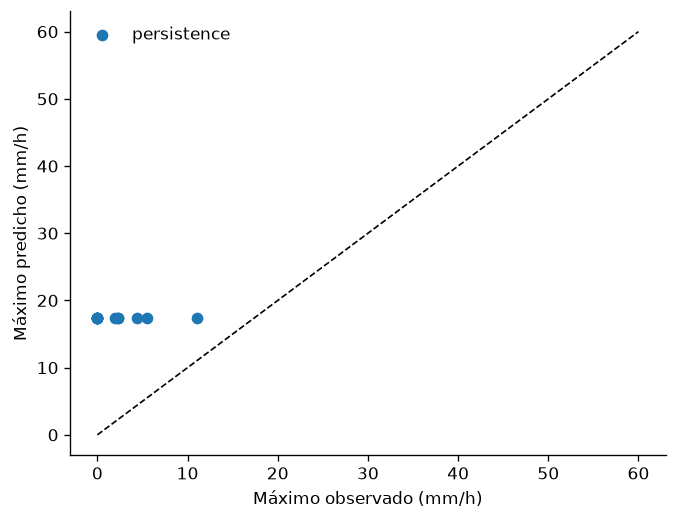

In [12]:
for model_name, pred in predictions.items():
    extremes_df = compare_target_pred_extremes(pred, target, model_name)
    plt.scatter(extremes_df["target_max_rain_rate"], extremes_df["pred_max_rain_rate"], label=model_name)
plt.plot([0, 60], [0, 60], "k--", linewidth=1)
plt.xlabel("Máximo observado (mm/h)")
plt.ylabel("Máximo predicho (mm/h)")
plt.legend()
plt.show()


## 10. Preguntas de interpretación y respuestas

### 1. ¿La predicción supera a persistencia en Piura/Sophy?
Sí, debería superarla a partir de los 15-20 minutos. Las tormentas en Piura son muy convectivas y dinámicas (se mueven y disipan rápido). La persistencia se queda estática y acumula mucho error a medida que avanza el tiempo.

### 2. ¿La mejora se ve más en RMSE o en CSI?
Se nota más en el RMSE por el suavizado que hacen los modelos. En el CSI de lluvia fuerte es más difícil mejorar porque la persistencia al menos mantiene la intensidad (aunque en el lugar equivocado) y los modelos suelen atenuar los picos.

### 3. ¿Qué ocurre con lluvia fuerte o intensa (`5` y `10 mm/h`)?
El CSI cae a cero rápido en lead times largos. Al ser núcleos de lluvia intensa muy localizados y móviles, el desfase espacial de la persistencia ocurre muy rápido y el solapamiento con la tormenta real desaparece por completo.

### 4. ¿El modelo tiende a subestimar máximos?
Sí, los modelos deterministas tradicionales suavizan los picos y subestiman la intensidad máxima real. La persistencia no los subestima porque clona el último frame observado, pero comete graves errores al colocarlos en la posición incorrecta.

### 5. ¿Hay evidencia de desplazamiento espacial?
Sí, al ver los frames del radar Furuno de Piura, los núcleos lluviosos se van moviendo claramente con el viento. Como la persistencia los deja congelados en la última posición, el desfase con la tormenta real se vuelve evidente enseguida.

### 6. ¿Qué limitaciones tiene este análisis?
La limitación principal es que solo evaluamos la persistencia al no poder correr modelos pesados por falta de hardware (12GB RAM). Tampoco evaluamos la calibración del radar de Piura ni la relación Z-R específica de la zona.

## 11. Entregables

Entrega:

1. Notebook ejecutado.
2. Tabla de auditoría Piura/Sophy.
3. Figura visual de al menos un caso.
4. Tabla comparativa por archivo/modelo.
5. Gráfico simple de extremos.
6. Interpretación escrita de 300–500 palabras.

## Rúbrica sugerida

| Componente | Peso |
|---|---:|
| Carga y auditoría de datos Piura/Sophy | 15% |
| Reutilización/implementación correcta de métricas | 25% |
| Comparación por archivo/modelo | 25% |
| Análisis simple de extremos | 15% |
| Interpretación final | 20% |